In [38]:
# Standard library imports
from pathlib import Path
from typing import Optional, Tuple
import warnings

# Third-party imports
import geopandas as gpd
import pandas as pd
import requests
from shapely.geometry import box
import folium
from folium import plugins
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML

import ipyleaflet
from urllib.parse import urlencode
from pyproj import Transformer, CRS

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# Set up matplotlib for inline plotting
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!")
print(f"\nLibrary Versions:")
print(f"  GeoPandas: {gpd.__version__}")
print(f"  Pandas: {pd.__version__}")
print(f"  Folium: {folium.__version__}")

✓ All libraries imported successfully!

Library Versions:
  GeoPandas: 1.1.1
  Pandas: 2.3.3
  Folium: 0.20.0


In [39]:
# Create data directory if it doesn't exist
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print(f"✓ Data directory ready: {DATA_DIR.absolute()}")

✓ Data directory ready: c:\Users\Steve\Documents\GitHub\PyDataVT2025\data


In [40]:
# API Endpoints
TOWN_BOUNDARIES_URL = (
    "https://services1.arcgis.com/BkFxaEFNwHqX3tAw/arcgis/rest/services/"
    "FS_VCGI_OPENDATA_Boundary_BNDHASH_poly_towns_SP_v1/FeatureServer/0/query"
    "?outFields=*&where=1%3D1&f=geojson"
)

GEOLOGY_MAPSERVICE_URL = (
    "https://anrmaps.vermont.gov/arcgis/rest/services/Open_Data/"
    "OPENDATA_ANR_GEOLOGIC_SP_NOCACHE_v2/MapServer/165"
)

GEOLOGY_QUERY_ENDPOINT = f"{GEOLOGY_MAPSERVICE_URL}/query"

BASEMAP_URL = (
    "https://basemaps.arcgis.com/arcgis/rest/services/"
    "World_Basemap_v2/VectorTileServer"
)

# Coordinate Reference Systems
# Note: GeoPandas accepts both "EPSG:####" and "####" formats
VT_STATE_PLANE = "EPSG:32145"  # Vermont State Plane NAD83 (meters)
WEB_MERCATOR = "EPSG:3857"      # Web Mercator (for tile services)
WGS84 = "EPSG:4326"             # WGS84 (latitude/longitude)

# File paths for cached data
TOWNS_CACHE = DATA_DIR / "towns.geojson"

# Create PyProj Transformer for coordinate conversions
# This transformer converts from WGS84 (lat/lon) to Vermont State Plane (meters)
wgs84_crs = CRS.from_epsg(4326)  # WGS84: latitude, longitude
vt_state_plane_crs = CRS.from_epsg(32145)  # Vermont State Plane: easting, northing

# Create transformer object (always_xy=True means input is longitude, latitude order)
transformer_wgs84_to_vtsp = Transformer.from_crs(wgs84_crs, vt_state_plane_crs, always_xy=True)

# Create reverse transformer for Vermont State Plane to WGS84
transformer_vtsp_to_wgs84 = Transformer.from_crs(vt_state_plane_crs, wgs84_crs, always_xy=True)

print("✓ Configuration complete!")
print(f"\nData Sources:")
print(f"  Towns: VCGI OpenData Portal")
print(f"  Geology: VT Agency of Natural Resources")
print(f"\nCoordinate Systems:")
print(f"  Vermont State Plane: {VT_STATE_PLANE}")
print(f"  WGS84 (Web): {WGS84}")
print(f"\nTransformers:")
print(f"  WGS84 → VT State Plane: transformer_wgs84_to_vtsp")
print(f"  VT State Plane → WGS84: transformer_vtsp_to_wgs84")

✓ Configuration complete!

Data Sources:
  Towns: VCGI OpenData Portal
  Geology: VT Agency of Natural Resources

Coordinate Systems:
  Vermont State Plane: EPSG:32145
  WGS84 (Web): EPSG:4326

Transformers:
  WGS84 → VT State Plane: transformer_wgs84_to_vtsp
  VT State Plane → WGS84: transformer_vtsp_to_wgs84


In [41]:
# define a function to fetch town boundaries
def fetch_town_boundaries(use_cache: bool = True) -> gpd.GeoDataFrame:
    """
    Fetch Vermont town boundaries from VCGI OpenData portal.
    
    Parameters
    ----------
    use_cache : bool, default True
        If True, load from local cache if available. Otherwise, fetch from API.
    
    Returns
    -------
    gpd.GeoDataFrame
        GeoDataFrame containing Vermont town boundaries in VT State Plane (EPSG:32145)
    
    Notes
    -----
    Data is cached to data/towns.geojson after first download.
    The source data is in WGS84 (lat/lon) and is transformed to VT State Plane (meters).
    """
    # Check if cached file exists and use_cache is True
    if use_cache and TOWNS_CACHE.exists():
        print(f"📁 Loading towns from cache: {TOWNS_CACHE}")
        gdf = gpd.read_file(TOWNS_CACHE)
        
        # IMPORTANT: GeoJSON is always in WGS84 (EPSG:4326)
        # We need to set the CRS and then transform to VT State Plane
        gdf = gdf.set_crs(WGS84, allow_override=True)
        gdf = gdf.to_crs(VT_STATE_PLANE)
        
        print(f"✓ Loaded {len(gdf)} towns from cache")
        print(f"✓ Transformed to {gdf.crs.name}")
        return gdf
    
    # Fetch from API
    print(f"🌐 Fetching town boundaries from VCGI...")
    print(f"   URL: {TOWN_BOUNDARIES_URL[:80]}...")
    
    try:
        # Make HTTP GET request
        response = requests.get(TOWN_BOUNDARIES_URL, timeout=30)
        response.raise_for_status()  # Raise exception for bad status codes
        
        # Parse GeoJSON response
        geojson_data = response.json()
        
        # Convert to GeoDataFrame
        gdf = gpd.GeoDataFrame.from_features(geojson_data['features'])
        
        # Set coordinate reference system
        # GeoJSON spec requires WGS84 (EPSG:4326) coordinates
        gdf = gdf.set_crs(WGS84)
        
        print(f"✓ Fetched {len(gdf)} town boundaries in WGS84")
        
        # Transform to Vermont State Plane for easier measurement in meters
        # IMPORTANT: to_crs() returns a NEW GeoDataFrame, it doesn't modify in place!
        gdf = gdf.to_crs(VT_STATE_PLANE)
        
        print(f"✓ Transformed to {gdf.crs.name}")
        
        # Save to cache (will be saved in VT State Plane coordinates)
        print(f"💾 Saving to cache: {TOWNS_CACHE}")
        gdf.to_file(TOWNS_CACHE, driver='GeoJSON')
        print(f"✓ Cache saved successfully")
        
        return gdf
        
    except requests.exceptions.RequestException as e:
        print(f"❌ Error fetching data: {e}")
        raise
    except Exception as e:
        print(f"❌ Error processing data: {e}")
        raise


In [42]:
# Fetch the data
towns_gdf = fetch_town_boundaries()

print(f"\n" + "="*50)
print("TOWN BOUNDARIES LOADED SUCCESSFULLY")
print("="*50)

📁 Loading towns from cache: data\towns.geojson
✓ Loaded 256 towns from cache
✓ Transformed to NAD83 / Vermont

TOWN BOUNDARIES LOADED SUCCESSFULLY
✓ Loaded 256 towns from cache
✓ Transformed to NAD83 / Vermont

TOWN BOUNDARIES LOADED SUCCESSFULLY


In [43]:
def on_town_selected(town_name: str) -> None:
    """
    Callback function when a town is selected from the dropdown.
    
    Parameters
    ----------
    town_name : str
        Name of the selected town
    """
    global selected_town_data, selected_town_name
    
    # Store the selected town name
    selected_town_name = town_name
    
    # Filter the GeoDataFrame to get the selected town
    selected_town_data = towns_gdf[towns_gdf[town_name_field] == town_name].copy()
    
    if len(selected_town_data) == 0:
        print(f"⚠️  No data found for town: {town_name}")
        return
    
    # Get the first (and should be only) row
    town = selected_town_data.iloc[0]
    
    # Display town information
    print("=" * 70)
    print(f"📍 SELECTED TOWN: {town_name}")
    print("=" * 70)
    
    # Display key attributes
    print(f"\nTown Information:")
    for col in selected_town_data.columns:
        if col != 'geometry':
            value = town[col]
            print(f"  • {col}: {value}")
    
    # Calculate and display area
    # Area is calculated in square meters (since CRS is in meters)
    area_sq_m = town.geometry.area
    area_sq_km = area_sq_m / 1_000_000
    area_acres = area_sq_m / 4046.86
    
    print(f"\nGeographic Properties:")
    print(f"  • Area: {area_sq_km:.2f} km² ({area_acres:.2f} acres)")
    
    # Get bounding box
    bounds = town.geometry.bounds
    print(f"  • Bounding Box (Vermont State Plane, meters):")
    print(f"      Min X: {bounds[0]:,.2f}")
    print(f"      Min Y: {bounds[1]:,.2f}")
    print(f"      Max X: {bounds[2]:,.2f}")
    print(f"      Max Y: {bounds[3]:,.2f}")
    
    # Calculate centroid
    centroid = town.geometry.centroid
    print(f"  • Centroid:")
    print(f"      X: {centroid.x:,.2f}")
    print(f"      Y: {centroid.y:,.2f}")
    
    print("\n" + "=" * 70)
    print("✓ Town data loaded and ready for mapping")
    print("=" * 70)

In [44]:
# Identify the town name column
# Common field names: TOWNNAME, TOWN, NAME, etc.
name_candidates = ['TOWNNAME', 'TOWN', 'NAME', 'Town', 'name']
town_name_field = None

town_name_field = "TOWNNAMEMC"

# Get sorted list of town names
town_names = sorted(towns_gdf[town_name_field].unique())

print(f"\n✓ Found {len(town_names)} Vermont towns")
print(f"\nTown name field: '{town_name_field}'")
print(f"\nSample towns (first 10):")
for name in town_names[:10]:
    print(f"  • {name}")
print(f"  ...")
print(f"  • {town_names[-1]}")


✓ Found 256 Vermont towns

Town name field: 'TOWNNAMEMC'

Sample towns (first 10):
  • Addison
  • Albany
  • Alburgh
  • Andover
  • Arlington
  • Athens
  • Averill
  • Avery's Gore
  • Bakersfield
  • Baltimore
  ...
  • Worcester


In [45]:
# Display first few towns
# Drop geometry column for cleaner display (it's very long)
display_cols = [col for col in towns_gdf.columns if col != 'geometry']

print("\nFirst 5 Towns:")
print("=" * 60)
towns_gdf[display_cols].head()


First 5 Towns:


,OBJECTID,FIPS6,TOWNNAME,TOWNNAMEMC,CNTY,TOWNGEOID,Shape__Area,Shape__Length
0,1,9030.0,CANAAN,Canaan,9,5000911800,8.613393e+07,63085.366335
1,2,11040.0,FRANKLIN,Franklin,11,5001127100,1.058529e+08,42591.256754
2,3,11015.0,BERKSHIRE,Berkshire,11,5001105425,1.085458e+08,42302.494352
3,4,11050.0,HIGHGATE,Highgate,11,5001133025,1.555736e+08,57367.840529
4,5,11060.0,RICHFORD,Richford,11,5001159125,1.118973e+08,42398.623987


In [46]:
# Display column names and types
print("Available Columns:")
print("=" * 60)
for col in towns_gdf.columns:
    dtype = towns_gdf[col].dtype
    if col != 'geometry':
        sample = towns_gdf[col].iloc[0] if len(towns_gdf) > 0 else None
        print(f"  {col:20s} ({dtype}) - Example: {sample}")
    else:
        print(f"  {col:20s} ({dtype})")

Available Columns:
  OBJECTID             (int32) - Example: 1
  FIPS6                (float64) - Example: 9030.0
  TOWNNAME             (object) - Example: CANAAN
  TOWNNAMEMC           (object) - Example: Canaan
  CNTY                 (int32) - Example: 9
  TOWNGEOID            (object) - Example: 5000911800
  Shape__Area          (float64) - Example: 86133926.42295837
  Shape__Length        (float64) - Example: 63085.36633522642
  geometry             (geometry)


In [47]:
# Display basic information
print("Dataset Shape:")
print(f"  Rows (towns): {len(towns_gdf)}")
print(f"  Columns (attributes): {len(towns_gdf.columns)}")

print(f"\nCoordinate Reference System:")
print(f"  {towns_gdf.crs}")
print(f"  Name: {towns_gdf.crs.name}")

print(f"\nGeometry Type:")
print(f"  {towns_gdf.geometry.type.unique()}")

print(f"\nBounding Box (in meters, Vermont State Plane):")
bounds = towns_gdf.total_bounds
print(f"  Min X: {bounds[0]:,.2f}")
print(f"  Min Y: {bounds[1]:,.2f}")
print(f"  Max X: {bounds[2]:,.2f}")
print(f"  Max Y: {bounds[3]:,.2f}")

Dataset Shape:
  Rows (towns): 256
  Columns (attributes): 9

Coordinate Reference System:
  EPSG:32145
  Name: NAD83 / Vermont

Geometry Type:
  ['Polygon' 'MultiPolygon']

Bounding Box (in meters, Vermont State Plane):
  Min X: 424,788.73
  Min Y: 25,212.80
  Max X: 581,554.29
  Max Y: 279,799.49


In [48]:
# Create output widget to capture display
output = Output()

print("🎛️  Interactive Town Selector")
print("=" * 70)
print("Select a Vermont town from the dropdown below to view its information.")
print("This will load the town's boundary data for mapping in the next step.")
print("=" * 70)

# Create the dropdown widget
town_dropdown = Dropdown(
    options=town_names,
    value=town_names[0],  # Default to first town
    description='Select Town:',
    style={'description_width': '100px'},
    layout={'width': '400px'}
)

C = town_names[0]

# Wrapper function to clear output before displaying
def update_town_display(town_name):
    with output:
        output.clear_output(wait=True)
        on_town_selected(town_name)

# Use Dropdown.observe instead of interact to avoid duplicate callbacks
def _on_dropdown_change(change):
    # Only respond to user-driven value changes
    if change.get('name') == 'value' and change.get('new') is not None:
        update_town_display(change.get('new'))

# Attach the observer
town_dropdown.observe(_on_dropdown_change, names='value')

# Display the dropdown and the output widget
display(town_dropdown)
display(output)

# The observer will now handle the initial population of the output
# when the dropdown is displayed.

🎛️  Interactive Town Selector
Select a Vermont town from the dropdown below to view its information.
This will load the town's boundary data for mapping in the next step.


Dropdown(description='Select Town:', layout=Layout(width='400px'), options=('Addison', 'Albany', 'Alburgh', 'A…

Output()

Creating map for: Richmond
🗺️  Generating map for Richmond...
   Town bounds (Vermont State Plane, meters):
      Min X (Easting):  453,657.97
      Min Y (Northing): 205,122.73
      Max X (Easting):  466,658.75
      Max Y (Northing): 214,952.49
   Padded bounds (with 10% buffer):
      452357.8930588139,204139.75140736962,467958.82632272714,215935.46903728426


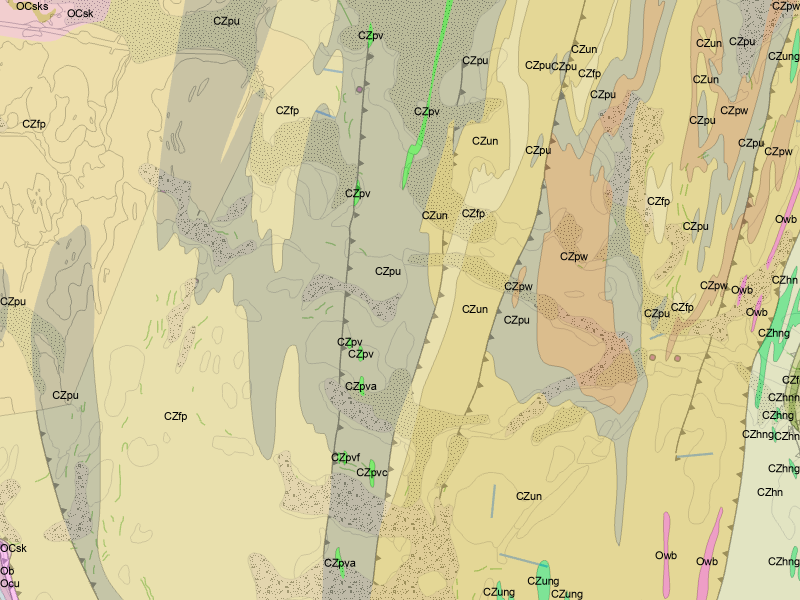


✓ Map displayed for Richmond
   Image size: 800x600 pixels
   Geology layer: Bedrock geology (Layer 165)
   Coordinate System: Vermont State Plane (EPSG:32145)


In [49]:
def create_town_map(town_name):
    """
    Create a static map image for the selected Vermont town using ArcGIS MapServer export.
    
    Parameters
    ----------
    town_name : str, optional
        Name of town to display. If None, uses globally selected town.
    
    Notes
    -----
    This uses the ArcGIS REST API 'export' endpoint to generate a static map image
    showing the geology layers for the town's bounding box.
    The town data is already in Vermont State Plane (EPSG:32145) coordinates,
    so we can use the bounds directly in meters.
    """
    # Use provided town name or fall back to global selection
    if town_name is None:
        if selected_town_name is None:
            print("⚠️  No town selected. Please select a town first.")
            return None
        town_name = selected_town_name
    
    # Get the town data
    town_data = towns_gdf[towns_gdf[town_name_field] == town_name].copy()
    
    if len(town_data) == 0:
        print(f"⚠️  No data found for town: {town_name}")
        return None
    
    # Get bounding box - town data is already in Vermont State Plane (EPSG:32145)
    # so bounds are already in meters
    bounds = town_data.total_bounds  # [minx, miny, maxx, maxy] in meters
    
    print(f"🗺️  Generating map for {town_name}...")
    print(f"   Town bounds (Vermont State Plane, meters):")
    print(f"      Min X (Easting):  {bounds[0]:,.2f}")
    print(f"      Min Y (Northing): {bounds[1]:,.2f}")
    print(f"      Max X (Easting):  {bounds[2]:,.2f}")
    print(f"      Max Y (Northing): {bounds[3]:,.2f}")
    
    # Add some padding (10% on each side) for better visualization
    width = bounds[2] - bounds[0]
    height = bounds[3] - bounds[1]
    padding_x = width * 0.1
    padding_y = height * 0.1
    
    # Create padded bounding box
    bbox_padded = [
        bounds[0] - padding_x,  # Min X (Easting)
        bounds[1] - padding_y,  # Min Y (Northing)
        bounds[2] + padding_x,  # Max X (Easting)
        bounds[3] + padding_y   # Max Y (Northing)
    ]
    
    # Format bbox as comma-separated string for the API
    bbox_str = ','.join(map(str, bbox_padded))
    
    print(f"   Padded bounds (with 10% buffer):")
    print(f"      {bbox_str}")
    
    # Construct the MapServer export URL
    base_url = "https://anrmaps.vermont.gov/arcgis/rest/services/Open_Data/OPENDATA_ANR_GEOLOGIC_SP_NOCACHE_v2/MapServer/export"
    
    # Build query parameters
    # Key point: bboxSR and imageSR are both 32145 (Vermont State Plane)
    # This ensures the map service interprets our bbox correctly
    params = {
        'bbox': bbox_str,
        'bboxSR': '32145',  # Spatial Reference of the bbox (Vermont State Plane)
        'imageSR': '32145',  # Spatial Reference for the output image
        'size': '800,600',
        'dpi': '96',
        'format': 'png32',
        'transparent': 'true',
        
        'f': 'image'
    }
    
    try:
        response = requests.get(base_url, params=params, timeout=30)
        response.raise_for_status()
        
        # Display the image
        from IPython.display import Image as IPImage
        display(IPImage(response.content))
        
        print(f"\n✓ Map displayed for {town_name}")
        print(f"   Image size: 800x600 pixels")
        print(f"   Geology layer: Bedrock geology (Layer 165)")
        print(f"   Coordinate System: Vermont State Plane (EPSG:32145)")
        
    except requests.exceptions.RequestException as e:
        print(f"❌ Error fetching map: {e}")
        raise

# Create and display the map for the selected town
if selected_town_name:
    print(f"Creating map for: {selected_town_name}")
    print("=" * 70)
    create_town_map(selected_town_name)
else:
    print("⚠️  Please select a town from the dropdown above first!")

In [50]:
# Interactive ipyleaflet Map with Dynamic ArcGIS MapServer Layer

def create_interactive_map(town_name=None):
    """
    Create an interactive ipyleaflet map with ArcGIS MapServer geology layer.
    
    Parameters
    ----------
    town_name : str, optional
        Name of town to center map on. If None, uses globally selected town.
    
    Returns
    -------
    ipyleaflet.Map
        Interactive map with dynamic geology layer and town boundary
    
    Notes
    -----
    This demonstrates how to:
    - Create an ipyleaflet map
    - Add a dynamic ArcGIS MapServer layer using ImageOverlay
    - Reproject map bounds from WGS84 to VT State Plane for API calls
    - Add town boundary as GeoJSON layer
    - Handle map interactions (pan/zoom) to update the layer
    """
    # Use provided town name or fall back to global selection
    if town_name is None:
        if selected_town_name is None:
            print("⚠️  No town selected. Please select a town first.")
            return None
        town_name = selected_town_name
    
    # Get the town data
    town_data = towns_gdf[towns_gdf[town_name_field] == town_name].copy()
    
    if len(town_data) == 0:
        print(f"⚠️  No data found for town: {town_name}")
        return None
    
    # Convert town to WGS84 for ipyleaflet (which uses WGS84)
    town_wgs84 = town_data.to_crs(WGS84)
    
    # Get town center and bounds in WGS84
    centroid = town_wgs84.geometry.centroid.iloc[0]
    center_lat = centroid.y
    center_lon = centroid.x
    
    # Calculate bounds for fitting
    bounds_wgs = town_wgs84.total_bounds  # [minx, miny, maxx, maxy]
    
    MAP_PIXEL_WIDTH = 800
    MAP_PIXEL_HEIGHT = 600

    # Create the ipyleaflet map centered on the town
    m = ipyleaflet.Map(
        center=(center_lat, center_lon),
        zoom=12,
        scroll_wheel_zoom=True,
    )

    
    
    # Add a basemap layer
    basemap = ipyleaflet.basemap_to_tiles(ipyleaflet.basemaps.OpenStreetMap.Mapnik)
    m.add_layer(basemap)
    
    # Create placeholder ImageOverlay for the geology layer
    # Start with a transparent 1x1 pixel image
    image_overlay = ipyleaflet.ImageOverlay(
        url="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAAEAAAABCAQAAAC1HAwCAAAAC0lEQVR42mNkYAAAAAYAAjCB0C8AAAAASUVORK5CYII=",
        bounds=((bounds_wgs[1], bounds_wgs[0]), (bounds_wgs[3], bounds_wgs[2])),
        name="Geology Layer"
    )
    m.add_layer(image_overlay)
    
    # Add town boundary as GeoJSON layer
    # Convert to GeoJSON format that ipyleaflet expects
    town_geojson = town_wgs84.__geo_interface__
    
    geo_json_layer = ipyleaflet.GeoJSON(
        data=town_geojson,
        style={
            'color': '#cc0000',
            'fillColor': '#ffcccc',
            'weight': 3,
            'fillOpacity': 0.2
        },
        hover_style={
            'color': '#ff0000',
            'fillColor': '#ff6666',
            'weight': 4,
            'fillOpacity': 0.4
        },
        name=f'{town_name} Boundary'
    )
    m.add_layer(geo_json_layer)
    
    # Define the interaction handler to update the geology layer
    def handle_interaction(change):
        """
        Called on pan/zoom. Gets map bounds in WGS84, transforms to VT State Plane,
        and constructs the Esri export URL.
        
        Parameters
        ----------
        change : dict
            Dictionary containing the change information from the observer
        """
        # Get current map bounds from ipyleaflet (in WGS84)
        # Format: ((south, west), (north, east))
        map_bounds_wgs = m.bounds
        
        # Extract coordinates
        south, west = map_bounds_wgs[0]
        north, east = map_bounds_wgs[1]
        
        # Use pyproj transformer to convert corners to VT State Plane
        # Bottom-left corner
        xmin_proj, ymin_proj = transformer_wgs84_to_vtsp.transform(west, south)
        # Top-right corner  
        xmax_proj, ymax_proj = transformer_wgs84_to_vtsp.transform(east, north)
        
        # Construct the Esri export URL using the projected bounds
        bbox_str = f'{xmin_proj},{ymin_proj},{xmax_proj},{ymax_proj}'
        
        # Get current map size for proper resolution
        width, height = 800, 800  # Default size
        if hasattr(m, 'size') and m.size:
            width, height = m.size[0], m.size[1]
            print(f"Map size: {width}x{height}")
        
        params = {
            'bbox': bbox_str,
            'bboxSR': '32145',  # Vermont State Plane
            'imageSR': '32145',  # Request image in VT State Plane
            'size': f'{width},{height}',
            'dpi': '96',
            'format': 'png32',
            'transparent': 'true',
            'f': 'image'
        }
        
        # Construct full URL
        base_url = "https://anrmaps.vermont.gov/arcgis/rest/services/Open_Data/OPENDATA_ANR_GEOLOGIC_SP_NOCACHE_v2/MapServer/export"
        new_url = f"{base_url}?{urlencode(params)}"
        
        # Update the ImageOverlay
        # URL: Use the new dynamic URL
        # Bounds: Use the ORIGINAL WGS84 bounds to position the image on the map
        image_overlay.url = new_url
        image_overlay.bounds = map_bounds_wgs
    
    # Link the function to map interaction events
    # The observer will automatically trigger when the map bounds change
    # (including when fit_bounds is called below)
    m.observe(handle_interaction, names=['bounds'])
    
    # Add layer control
    layer_control = ipyleaflet.LayersControl(position='topright')
    m.add_control(layer_control)
    
    # Fit map to town bounds - this will trigger handle_interaction via the observer
    m.fit_bounds([[bounds_wgs[1], bounds_wgs[0]], [bounds_wgs[3], bounds_wgs[2]]])
    
    print(f"✓ Interactive map created for {town_name}")
    print(f"  Center: ({center_lat:.4f}, {center_lon:.4f})")
    print(f"  Layers: Basemap, Geology (dynamic), Town Boundary")
    print(f"  Pan and zoom to explore - geology layer updates dynamically!")
    
    map_layout = widgets.Layout(width='800px', height='800px')

    m.layout = map_layout

    return m

# Create and display the interactive map
if selected_town_name:
    print(f"Creating interactive map for: {selected_town_name}")
    print("=" * 70)
    interactive_map = create_interactive_map()
    display(interactive_map)
else:
    print("⚠️  Please select a town from the dropdown above first!")

Creating interactive map for: Richmond
✓ Interactive map created for Richmond
  Center: (44.3942, -72.9932)
  Layers: Basemap, Geology (dynamic), Town Boundary
  Pan and zoom to explore - geology layer updates dynamically!


Map(center=[44.39422652995912, -72.99319339325312], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [ ]:
# geologic map legend service
# https://ngmdb-tiles.usgs.gov/api/ngs/polys/esurf/legend/synthesis/?aoi=-73.636,44.245,-72.634,44.695

# given the bounds of the above map in lat/long, read the JSON of that endpoint and create a legend with a colored shape, abbreviation, name, and description 
# compact view

# Sample JSON

# {
# 	"count": 15,
# 	"next": null,
# 	"previous": null,
# 	"results": [
# 		{
# 			"code": "water",
# 			"name": "Water and ice (Modern)",
# 			"description": "Primarily water bodies, locally includes glacial ice.",
# 			"rgba": "204,255,255,1",
# 			"sym": "9"
# 		},
# 		{
# 			"code": "Qs",
# 			"name": "Clastic sediments, undifferentiated (Quaternary)",
# 			"description": "Undifferentiated clastic sediments, including alluvium, glacial deposits, and landslide deposits.",
# 			"rgba": "255,255,204,1",
# 			"sym": "16"
# 		},
# 		{
# 			"code": "Qg",
# 			"name": "Glacial till, undifferentiated (Quaternary)",
# 			"description": "Undifferentiated glacial till and local outwash or other ice-contact and ice-marginal deposits. Primarily deposits associated with the most recent glaciation, but locally includes units categorized broadly as Pleistocene or Quaternary.",
# 			"rgba": "235,235,179,1",
# 			"sym": "8"
# 		},
#         ...